In [1]:
import yaml, torch, sys
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch.nn.functional as F
import random as random
import re
import torch, json, random, os
from PIL import Image
# import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
# import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from torch.utils.data import random_split
from types import SimpleNamespace
#add more packages here
sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device

In [2]:

sys.path.insert(0, '../../')
from utils.train_model import set_seed, get_device

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_03_01.yaml') as f:
    config.update(yaml.safe_load(f))
    
    

def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

config = to_namespace(config)

set_seed(config.seed)
device = get_device()

RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)


data_dir = Path("./EX_01/Raw/")

[device] using cpu


/ihome/xli/sek188/.conda/envs/teamMavConda/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


# Context
This is the first experiment of the third epic. Its purpose is to improve training stability and final reconstruction quality by restructuring *how* the two-term loss is applied over time, rather than changing the model architecture or data pipeline.

In all previous experiments, the pre-blur confusion loss and post-blur similarity loss were weighted and applied simultaneously from the start of training. This creates a tension early in training: the model is being penalized for recognizability before it has learned what a well-reconstructed blurred digit looks like. Curriculum learning addresses this by scheduling loss weights across epochs — prioritizing post-blur similarity early so the model first learns the reconstruction target, then gradually introducing the pre-blur confusion penalty as training stabilizes.

No changes are made to the model architecture, data pipeline, or blur method. The only modification is to the training loop.

# Hypothesis
A curriculum-scheduled two-term loss — ramping from reconstruction-dominant to confusion-dominant across training — will produce lower post-blur MSE and higher pre-blur classifier confusion than a fixed-weight loss trained for the same number of epochs. We expect the model to find better optima by learning what to reconstruct before learning how to hide it.

# Implementation

## Loss Schedule
Training is divided into three phases:
- **Phase 1** (early epochs): post-blur MSE loss only. The model learns the reconstruction target with no adversarial pressure.
- **Phase 2** (middle epochs): both terms active, with MSE weighted higher. Confusion penalty is introduced gradually.
- **Phase 3** (final epochs): both terms active at target weight ratio. This matches the loss structure used in EX_04 for direct comparison.

Exact epoch boundaries and weight ramp function (linear vs. stepped) are treated as hyperparameters.

## Data
Same as EX_04: 4-channel composite images with synthetically generated gradient backgrounds and MNIST glyphs on a single channel.

## Evaluation
Results are compared directly against EX_04 (same architecture, fixed-weight loss) on pre-blur classifier confidence and post-blur MSE. A successful result shows lower MSE and/or lower pre-blur confidence at matched epoch count.

# Notes
If Phase 1 alone produces competitive MSE, that's a meaningful finding — it would suggest the confusion term is largely free-riding on the reconstruction gradient rather than contributing independently.

# Code


In [3]:
def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

In [4]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)


class ex02a(Dataset):
    def __init__(self, batch_size, transform=None):
        self.pairings = pd.read_csv(Path(config.csv_path))
        self.gradients_dir = Path(config.grad_dir)
        self.transform = transform if transform is not None else transforms.ToTensor()
        self.mnist     = datasets.MNIST('../../data/', train=True, download=False,
                                        transform=transforms.ToTensor())

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann = self.pairings.iloc[idx]
        if not isinstance(ann["gradient_path"], str):
            raise Exception ("huhhh")
        b_img_path =  "../../Epic_1/EX_01/" + ann["gradient_path"]
        b = self.transform(Image.open(b_img_path).convert("RGB")) 
        i, lab = self.mnist[int(ann["mnist_idx"])]

        comp = torch.cat([b, i], dim=0)  # (4, H, W)
        return comp, lab
    
    def __getitems__(self, indices):
        return [self[i] for i in indices]

ex02a_trainset = ex02a(batch_size = config.batch_size)
# ex02a_trainloader = DataLoader(ex02a_trainset, batch_size=config.batch_size, shuffle=True)
# ex02a_valloader = DataLoader(ex02a_trainset, batch_size=config.batch_size, shuffle=True)



n = len(ex02a_trainset)
train_size = int(0.9 * n)
val_size   = n - train_size

train_set, val_set = random_split(ex02a_trainset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(config.seed))

ex02a_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex02a_valloader   = DataLoader(val_set,   batch_size=config.batch_size)


In [6]:
def bandwtn(image):
    # image shape: (B, C, H, W)
    if image.shape[1] == 3:
        gray = (
            0.299 * image[:, 0:1] +
            0.587 * image[:, 1:2] +
            0.114 * image[:, 2:3]
        )
        # repeat to 3 channels to match input
        return gray.repeat(1, 3, 1, 1)
    
    elif image.shape[1] == 1:
        # already grayscale, just return
        return image
    
    else:
        raise ValueError(f"Unsupported number of channels: {image.shape[1]}")

In [7]:
#model

class singleBlock0cBlurredGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(12, 128),
            nn.ReLU(),
            nn.Linear(128, 7*7*32),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),   # 28x28
            nn.Sigmoid()
        )
    
    def forward(self, label_onehot):
        return self.net(label_onehot)



def ex3_01a_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch
    b, i  = comp[:, :3], comp[:, 3:]
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=10).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x)
    
    conf_pre, pred_pre  = m_classify_3d_with_conf(generated, label)

    #curriculum bit
    t = epoch / config.variants.a.epochs
    alpha_w = max(0.0, (t - 0.33) / 0.67)   # kicks in at 1/3
    gamma_w = max(0.0, (t - 0.66) / 0.34)   # kicks in at 2/3
    

    
    generated_1d = generated.mean(dim=1, keepdim=True) 
    blurred_real = box_blur(i, kernel_size=3) #no-op
    blurred_gen  = box_blur(generated_1d)

    bandwtn_blurred = bandwtn(blurred_gen) #bandwtn bc mnist is bandw, easier than trying to retrain and all we care about.
    post_loss    = F.mse_loss(bandwtn_blurred, blurred_real)

    delta_vis = (
            config.variants.a.beta  *              post_loss +
            config.variants.a.alpha * alpha_w  *  conf_pre 
    )
    loss = (delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "post_loss": post_loss.item(),
            "delta_vis": delta_vis.mean().item()
        }
    return loss


# ── RUN ───────────────────────────────────────────────────────────────────────
ex_03_01a_info = {
    "exp_id":      "EX_03_01a",
    "epochs":      config.variants.a.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}

model_03_1a = singleBlock0cBlurredGenerator()
optimizer = torch.optim.Adam(model_03_1a.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../../Epic_1/EX_01/Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
b_model.eval()


def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred


n = len(ex02a_trainset)
train_size = int(0.9 * n)
val_size   = n - train_size

subset = torch.utils.data.Subset(ex02a_trainset, random.sample(range(len(ex02a_trainset)), n))
train_set, val_set = random_split(subset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(config.seed))

ex_03_01a_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex_03_01a_valloader   = DataLoader(val_set,   batch_size=config.batch_size)


In [8]:
run_experiment(
    model=model_03_1a,
    optimizer=optimizer,
    loss_fn=ex3_01a_loss_fn,
    train_loader=ex_03_01a_trainloader,
    val_loader=ex_03_01a_valloader,
    config=ex_03_01a_info,
    log_to=ex_03_01a_info["log_to"],
)

[device] using cpu


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /ihome/xli/sek188/.netrc.
wandb: Currently logged in as: sek188 (teamMaverick) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


conf_pre,▇██▁▁▁▁▁▁▁
delta_vis,▁▁▁▂▃▄▅▆▇█
epoch,▁▂▃▃▄▅▆▆▇█
post_loss,█▃▁▆▄▄▃▃▂▂
train_loss,▁▁▁▂▃▄▅▆▇█
val_loss,▁▁▁▂▃▄▅▆▇█
conf_pre,0.09982
delta_vis,0.06954
epoch,10
post_loss,0.03253
train_loss,0.06925


singleBlock0cBlurredGenerator(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): Sigmoid()
  )
)

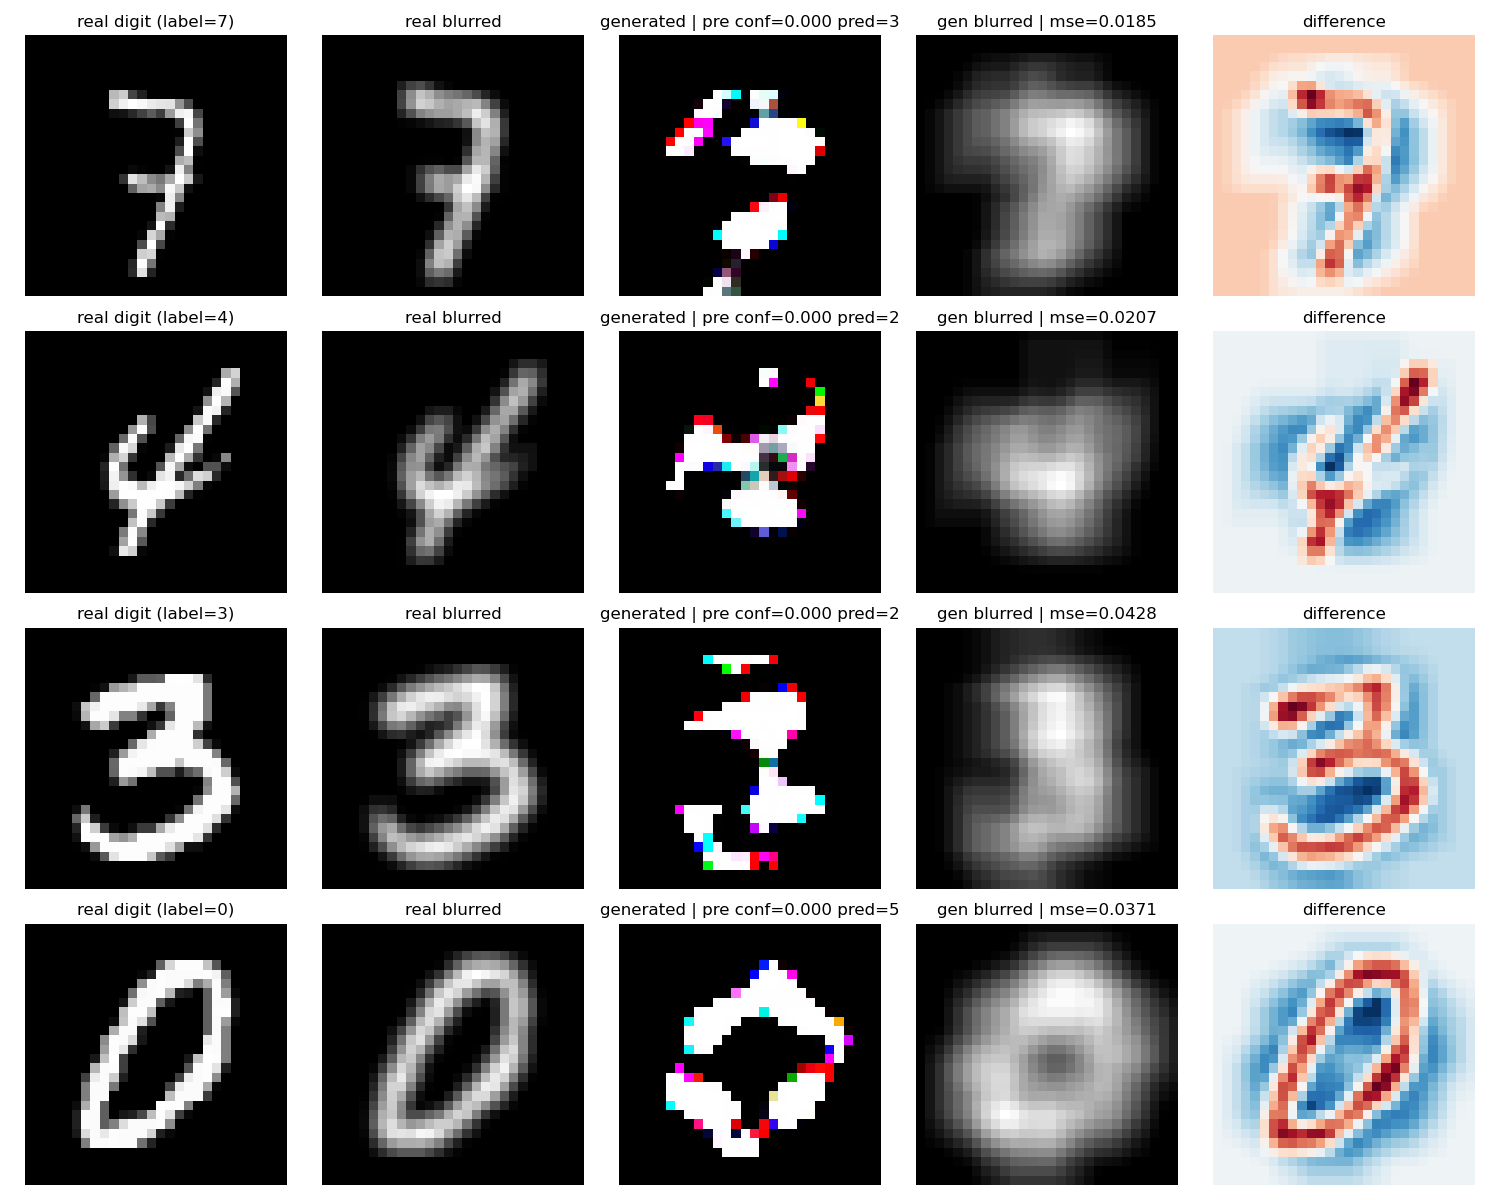

In [9]:
def show_generated(model, dataset, n=4, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 5, figsize=(15, n*3))
    
    with torch.no_grad():
        for row in range(n):
            comp, label_int = dataset[random.randint(0, len(dataset)-1)]
            label  = torch.tensor([label_int]).to(device)
            i      = comp[3:].unsqueeze(0).to(device)  # real digit (1, 1, 28, 28)
            
            noise   = torch.randn(1, 2).to(device)
            onehot  = F.one_hot(label, num_classes=10).float()
            x       = torch.cat([onehot, noise], dim=1)
            
            generated    = model(x)
            generated_1d = generated.mean(dim=1, keepdim=True)
            blurred_gen  = box_blur(generated_1d)
            blurred_real = box_blur(i, kernel_size=3) #no-op
            post_loss    = F.mse_loss(blurred_gen, blurred_real).item()
            
            conf_pre, pred_pre = m_classify_3d_with_conf(generated, label)

            axes[row, 0].imshow(i.squeeze().cpu(), cmap="gray")
            axes[row, 0].set_title(f"real digit (label={label_int})")
            axes[row, 1].imshow(blurred_real.squeeze().cpu(), cmap="gray")
            axes[row, 1].set_title("real blurred")
            axes[row, 2].imshow(generated.squeeze(0).cpu().permute(1,2,0))
            axes[row, 2].set_title(f"generated | pre conf={conf_pre.item():.3f} pred={pred_pre.item()}")
            axes[row, 3].imshow(blurred_gen.squeeze().cpu(), cmap="gray")
            axes[row, 3].set_title(f"gen blurred | mse={post_loss:.4f}")
            axes[row, 4].imshow((blurred_gen - blurred_real).squeeze().cpu(), cmap="RdBu")
            axes[row, 4].set_title("difference")
            for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig("Results/EX04_generated.png")
    plt.close()
    
    from IPython.display import Image as IPImage, display
    display(IPImage("Results/EX04_generated.png"))

show_generated(model_03_1a, train_set)